In [ ]:
!pip install numba numpy

In [ ]:
import numpy as np
import time

def generate_matrix(n, m):
    return np.random.rand(n, m).astype(np.float32)

def matmul_cpu(A, B):
    n, m = A.shape
    m2, k = B.shape

    assert m == m2, "Матрицы несовместимы"

    C = np.zeros((n, k), dtype=np.float32)

    for i in range(n):
        for j in range(k):
            for t in range(m):
                C[i, j] += A[i, t] * B[t, j]

    return C


N = 100
A = generate_matrix(N, N)
B = generate_matrix(N, N)

start = time.time()
C = matmul_cpu(A, B)
end = time.time()

print("CPU time:", end - start)

CPU time: 0.5573294162750244


In [ ]:
C_np = np.dot(A, B)

print("разница:", np.max(np.abs(C - C_np)))

разница: 1.335144e-05


In [ ]:
from numba import cuda
import math

@cuda.jit
def matmul_gpu(A, B, C):
    row, col = cuda.grid(2)

    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0.0
        for k in range(A.shape[1]):
            tmp += A[row, k] * B[k, col]

        C[row, col] = tmp

In [ ]:
N = 100

A = generate_matrix(N, N)
B = generate_matrix(N, N)

start = time.time()
C_cpu = matmul_cpu(A, B)
end = time.time()
print("CPU time:", end - start)

A_device = cuda.to_device(A)
B_device = cuda.to_device(B)
C_device = cuda.device_array((N, N))

threads_per_block = (16, 16)
blocks_per_grid = (
    math.ceil(N / 16),
    math.ceil(N / 16)
)

matmul_gpu[blocks_per_grid, threads_per_block](A_device, B_device, C_device)
cuda.synchronize()

start = time.time()
matmul_gpu[blocks_per_grid, threads_per_block](A_device, B_device, C_device)
cuda.synchronize()
end = time.time()

C_gpu = C_device.copy_to_host()

print("GPU time:", end - start)

print("Разница:", np.max(np.abs(C_cpu - C_gpu)))

CPU time: 0.5852539539337158
GPU time: 0.00024890899658203125
Разница: 1.4249235391616821e-05


In [ ]:
def run_experiment(N):
    print(f"\nРазмер: {N}x{N}")

    A = generate_matrix(N, N)
    B = generate_matrix(N, N)

    start = time.time()
    C_cpu = matmul_cpu(A, B)
    cpu_time = time.time() - start

    start = time.time()

    A_device = cuda.to_device(A)
    B_device = cuda.to_device(B)
    C_device = cuda.device_array((N, N))

    threads_per_block = (16, 16)
    blocks_per_grid = (
        math.ceil(N / 16),
        math.ceil(N / 16)
    )

    matmul_gpu[blocks_per_grid, threads_per_block](A_device, B_device, C_device)
    cuda.synchronize()

    C_gpu = C_device.copy_to_host()

    gpu_time = time.time() - start

    diff = np.max(np.abs(C_cpu - C_gpu))

    speedup = cpu_time / gpu_time

    print(f"CPU: {cpu_time:.4f} сек")
    print(f"GPU: {gpu_time:.4f} сек")
    print(f"Speedup: {speedup:.2f}x")
    print(f"Разница: {diff:.6f}")

    return cpu_time, gpu_time, speedup

In [ ]:
sizes = [100, 300, 500, 800]

results = []

for N in sizes:
    results.append((N, *run_experiment(N)))


Размер: 100x100
CPU: 0.7180 сек
GPU: 0.0012 сек
Speedup: 609.29x
Разница: 0.000015

Размер: 300x300
CPU: 16.1076 сек
GPU: 0.0029 сек
Speedup: 5464.26x
Разница: 0.000091

Размер: 500x500
CPU: 76.7064 сек
GPU: 0.0092 сек
Speedup: 8333.25x
Разница: 0.000173

Размер: 800x800
CPU: 319.4392 сек
GPU: 0.0319 сек
Speedup: 10023.30x
Разница: 0.000427


Графики

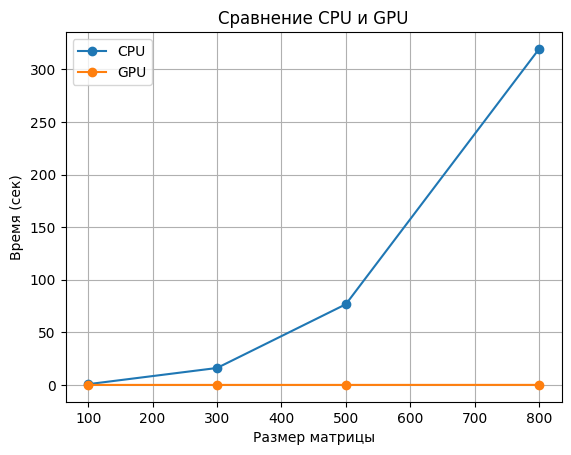

In [ ]:
import matplotlib.pyplot as plt

sizes = [100, 300, 500, 800]
cpu_times = [0.7180, 16.1076, 76.7064, 319.4392]
gpu_times = [0.0012, 0.0029, 0.0092, 0.0319]

plt.figure()
plt.plot(sizes, cpu_times, marker='o', label='CPU')
plt.plot(sizes, gpu_times, marker='o', label='GPU')
plt.xlabel('Размер матрицы')
plt.ylabel('Время (сек)')
plt.title('Сравнение CPU и GPU')
plt.legend()
plt.grid()

plt.show()

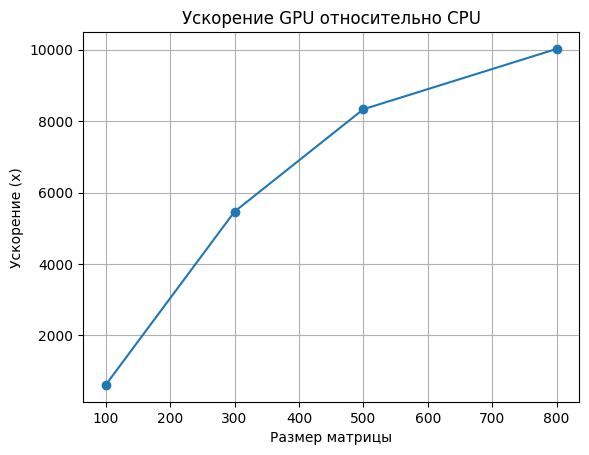

In [ ]:
speedups = [609.29, 5464.26, 8333.25, 10023.30]

plt.figure()
plt.plot(sizes, speedups, marker='o')
plt.xlabel('Размер матрицы')
plt.ylabel('Ускорение (x)')
plt.title('Ускорение GPU относительно CPU')
plt.grid()

plt.show()